In [1]:
import ants
import numpy as np
from skimage.filters import gaussian
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from skimage.exposure import equalize_adapthist

In [2]:
img3d = ants.image_read("1475083Dflair.nii")
img2d = ants.image_read("147508T2W_FLAIR.nii")

In [3]:
def verify_lpi(img):
    direction = np.array(img.direction)
    if direction.shape != (3,3): 
        print("warning, this isn't the right direction fix")
    print("direction matrix:")
    print(direction)
    return direction

In [4]:
def enforce_lpi(img):
    img_lpi = ants.reorient_image2(img, "LPI")
    return img_lpi

In [5]:
def bias_correct(img):
    mask = ants.get_mask(img)
    corrected = ants.n4_bias_field_correction(
        image=img,
        mask=mask
    )
    return corrected
#[4] Tustison, N.J., Avants, B.B., Cook, P.A., Zheng, Y., Egan, A., Yushkevich, P.A., & Gee, J.C. (2010). N4ITK: Improved N3 bias correction. IEEE Transactions on Medical Imaging, 29(6), 1310–1320. https://doi.org/10.1109/TMI.2010.2046908

In [6]:
def extract_metadata(img):
    spacing = img.spacing
    origin = img.origin
    direction = img.direction
    shape = img.shape
    print("Spacing:", spacing)
    print("origin:", origin)
    print("shape:", shape)
    return spacing, origin, direction

In [7]:
def compute_sigma(img3d, slice_thickness=None):
    if slice_thickness is None:
        slice_thickness = img3d.spacing[2]  # fallback
    z_spacing = img3d.spacing[2]
    sigma_mm = slice_thickness / 2.355
    sigma_vox = sigma_mm / z_spacing
    return sigma_vox, slice_thickness

In [8]:
def smooth_z(arr3d, sigma_vox):
    arr3d_smooth = gaussian(
        arr3d,
        sigma=(0, 0, sigma_vox),
        preserve_range=True
    )
    return arr3d_smooth

In [9]:
def slice_profile_kernel(slice_thickness_vox, width=7):
    z = np.linspace(-width, width, int(2 * width * slice_thickness_vox) + 1)
    sinc = np.sinc(z / slice_thickness_vox)
    window = np.hamming(len(sinc))
    kernel = sinc * window
    kernel = kernel / np.sum(kernel)
    return kernel

def apply_slice_profile(arr3d, slice_thickness_vox):
    kernel = slice_profile_kernel(slice_thickness_vox)
    arr3d_filtered = np.zeros_like(arr3d)
    for x in range(arr3d.shape[0]):
        for y in range(arr3d.shape[1]):
            signal = arr3d[x, y, :]
            filtered = np.convolve(signal, kernel, mode="same")
            arr3d_filtered[x, y, :] = filtered
    return arr3d_filtered
#[5] Rousseau, F., Kim, K., Studholme, C., Koob, M., & Dietemann, J.L. (2010). Robust super-resolution reconstruction of brain MRI. Proc. MICCAI Workshop on Brain Analysis using Connectivity and Imaging (BACI). (Classic reference for Gaussian PSF along slice direction)
#[6] Pham, C.H., et al. (2017). Multiscale brain MRI super-resolution using deep 3D convolutional networks. Computerized Medical Imaging and Graphics, 77, 101647. (Establishes Gaussian slice profile approximation: σ = slice_thickness / 2.355)

In [10]:
from scipy.ndimage import convolve1d
def apply_slice_profile(arr3d, slice_thickness_vox):
    from scipy.ndimage import gaussian_filter1d
    # axis=2 is the slice/Z direction
    filtered = gaussian_filter1d(arr3d, sigma=slice_thickness_vox / 2.355, axis=2)
    return filtered
def project_2d(arr3d, img3d, img2d_full):
    z_pos_2d = img2d_full.origin[2]
    z_origin_3d = img3d.origin[2]
    z_spacing_3d = img3d.spacing[2]
    z_idx = int(round((z_pos_2d - z_origin_3d) / z_spacing_3d))
    z_idx = np.clip(z_idx, 0, arr3d.shape[2] - 1)
    print(f"2D slice z-position: {z_pos_2d:.2f} mm")
    print(f"Matched to 3D z-index: {z_idx} of {arr3d.shape[2]}")
    return arr3d[:, :, z_idx]

In [11]:
def register_3d_to_2d_space(img3d, img2d_full):
    mask3d = ants.get_mask(img3d)
    mask2d = ants.get_mask(img2d_full)

    # Step 1: Rigid (translation + rotation)
    rigid = ants.registration(
        fixed=img2d_full,
        moving=img3d,
        type_of_transform='Rigid',
        mask=mask2d,
        moving_mask=mask3d,
        aff_metric='mattes',
        aff_sampling=64,
        grad_step=0.1,
        reg_iterations=(500, 250, 100),
        verbose=False
    )

    # Step 2: Affine (adds scaling/shear) initialized from rigid
    affine = ants.registration(
        fixed=img2d_full,
        moving=rigid['warpedmovout'],
        type_of_transform='Affine',
        mask=mask2d,
        aff_metric='mattes',
        aff_sampling=64,
        grad_step=0.05,
        reg_iterations=(200, 100, 50),
        verbose=False
    )

    print("3D→2D-space registration complete.")
    return affine['warpedmovout']

#[1] Avants, B.B., Epstein, C.L., Grossman, M., & Gee, J.C. (2008). Symmetric diffeomorphic image registration with cross-correlation: Evaluating automated labeling of elderly and neurodegenerative brain. Medical Image Analysis, 12(1), 26–41. https://doi.org/10.1016/j.media.2007.06.004
#[2] Avants, B.B., Tustison, N.J., Song, G., Cook, P.A., Klein, A., & Gee, J.C. (2011). A reproducible evaluation of ANTs similarity metric performance in brain image registration. NeuroImage, 54(3), 2033–2044. https://doi.org/10.1016/j.neuroimage.2010.09.025
#[3] Tustison, N.J., et al. (2021). The ANTsX ecosystem for quantitative biological and medical imaging. Scientific Reports, 11, 9068. https://doi.org/10.1038/s41598-021-87564-6

In [12]:
def refine_2d_alignment(sim_img, real_img):
    mask = ants.get_mask(real_img)
    refined = ants.registration(
        fixed=real_img,
        moving=sim_img,
        type_of_transform='SyNOnly',
        mask=mask,
        reg_iterations=(100, 50, 25),
        flow_sigma=2,
        total_sigma=0,
        aff_metric='mattes',
        aff_sampling=32,
        verbose=False
    )
    return refined['warpedmovout']

In [13]:
def numpy_to_ants_2d(arr2d, reference_2d_img):
    sim_img = ants.from_numpy(arr2d.astype(np.float32))
    sim_img.set_spacing((reference_2d_img.spacing[0], reference_2d_img.spacing[1]))
    sim_img = ants.copy_image_info(reference_2d_img, sim_img)
    return sim_img

In [14]:
def resample_to_target(sim_img, target_img, slice_thickness):
    sim_resampled = ants.resample_image(
        sim_img,
        (target_img.shape[0], target_img.shape[1]),
        use_voxels=True,
        interp_type=1
    )
    # Force to 2D if ANTs added a singleton dimension
    if sim_resampled.dimension == 3:
        arr = sim_resampled.numpy()[:, :, 0]
        sim_resampled = ants.from_numpy(arr.astype(np.float32))
        sim_resampled.set_spacing((target_img.spacing[0], target_img.spacing[1]))
    return sim_resampled

In [15]:
def affine_align(moving, fixed):
    # Center of mass initialization — critical for correcting rotation
    init_tx = ants.registration(
        fixed=fixed,
        moving=moving,
        type_of_transform='Translation'
    )['warpedmovout']
    
    rigid = ants.registration(
        fixed=fixed,
        moving=init_tx,
        type_of_transform="Rigid",
        reg_iterations=(500, 250, 100)
    )
    
    affine = ants.registration(
        fixed=fixed,
        moving=rigid["warpedmovout"],
        type_of_transform='Affine',
        aff_metric='mattes',
        aff_sampling=64,
        grad_step=0.1,
        flow_sigma=3,
        total_sigma=0,
        reg_iterations=(1000, 500, 250, 100)
    )
    
    syn = ants.registration(
        fixed=fixed,
        moving=affine["warpedmovout"],
        type_of_transform='SyNOnly',
        reg_iterations=(100, 50, 25),
        flow_sigma=3,
        total_sigma=0
    )
    return syn["warpedmovout"]

#[7] Busse, R.F., et al. (2008). Three-dimensional fluid-attenuated inversion recovery imaging with isotropic resolution and nonselective adiabatic inversion provides improved 3D visualization and CSF suppression compared to 2D FLAIR at 3 Tesla. Investigative Radiology, 43(8), 547–557. https://doi.org/10.1097/RLI.0b013e3181727706
#[8] Oguz, K.K., et al. (2012). Pitfalls of 3D FLAIR brain imaging: A prospective comparison with 2D FLAIR. Academic Radiology, 19(11), 1404–1411. https://doi.org/10.1016/j.acra.2012.06.007

In [16]:
def histogram_match(moving, fixed):
    matched = ants.histogram_match_image(
        moving,
        fixed,
        number_of_histogram_bins=256,
        number_of_match_points=25
    )
    return matched
#[10] Nyúl, L.G., Udupa, J.K., & Zhang, X. (2000). New variants of a method of MRI scale standardization. IEEE Transactions on Medical Imaging, 19(2), 143–150. https://doi.org/10.1109/42.836373

In [17]:
def create_mask(img):
    mask = ants.get_mask(img)
    return mask

In [18]:
def apply_mask(img, mask):
    return img * mask

In [19]:
def normalize(arr):
    arr = arr.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min())
    return arr

In [20]:
def compute_ssim_masked(real_img, sim_img, mask):
    real = normalize(real_img.numpy())
    sim = normalize(sim_img.numpy())
    mask_arr = mask.numpy() > 0

    
    real_masked = real * mask_arr
    sim_masked = sim * mask_arr

    score = ssim(real_masked, sim_masked, data_range=1.0)
    return score
#[9] Wang, Z., Bovik, A.C., Sheikh, H.R., & Simoncelli, E.P. (2004). Image quality assessment: From error visibility to structural similarity. IEEE Transactions on Image Processing, 13(4), 600–612. https://doi.org/10.1109/TIP.2003.819861

In [21]:
def compute_psnr(real_img, sim_img):

    real = normalize(real_img.numpy())
    sim = normalize(sim_img.numpy())

    mse = np.mean((real - sim) ** 2)

    if mse == 0:
            return 100

    psnr = 20 * np.log10(1.0 / np.sqrt(mse))

    return psnr

In [22]:
def compute_ncc(real_img, sim_img):

    r = normalize(real_img.numpy()).flatten()
    s = normalize(sim_img.numpy()).flatten()

    r_mean = r - np.mean(r)
    s_mean = s - np.mean(s)

    numerator = np.sum(r_mean * s_mean)

    denominator = np.sqrt(
        np.sum(r_mean**2) *
        np.sum(s_mean**2)
    )

    return numerator / denominator

In [23]:
def visualize(real, simulated):
    real_arr = real.numpy()
    sim_arr = simulated.numpy()

    # Use the same vmin/vmax for both so contrast is comparable
    vmin = min(real_arr.min(), sim_arr.min())
    vmax = max(real_arr.max(), sim_arr.max())

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.title("Real 2D FLAIR")
    plt.imshow(real_arr, cmap="gray", vmin=vmin, vmax=vmax)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Simulated from 3D")
    plt.imshow(sim_arr, cmap="gray", vmin=vmin, vmax=vmax)
    plt.axis("off")

    plt.show()

In [24]:
def extract_matched_slice(img3d, img2d_full):
    
    img3d_resampled = ants.resample_image_to_target(
        img3d,
        img2d_full,
        interp_type=1
    )
    
    
    arr = img3d_resampled.numpy()
    mid = arr.shape[2] // 2
    
    print(f"Extracting slice {mid} from resampled volume shape {arr.shape}")
    
    return arr[:, :, mid]

In [25]:
def apply_intensity_clip(arr, percentile=99):
    upper = np.percentile(arr, percentile)
    return np.clip(arr, 0, upper)

In [26]:
def enhance_csf_suppression(arr_sim, arr_real):
    """
    Explicitly darkens CSF/ventricle voxels in simulated image
    to match the suppression level seen in real 2D FLAIR.
    """
    # Define brain region (exclude background)
    brain_mask = arr_sim > np.percentile(arr_sim, 5)
    brain_vals_sim = arr_sim[brain_mask]
    brain_vals_real = arr_real[brain_mask]

    # CSF in FLAIR = darkest ~10% of brain voxels
    csf_thresh_sim = np.percentile(brain_vals_sim, 10)
    csf_thresh_real = np.percentile(brain_vals_real, 10)

    # White matter reference level (mid-high intensity)
    wm_sim = np.percentile(brain_vals_sim, 75)
    wm_real = np.percentile(brain_vals_real, 75)

    arr_out = arr_sim.copy()

    # For voxels below CSF threshold, scale them down to match real suppression
    csf_mask = (arr_sim < csf_thresh_sim) & brain_mask
    if csf_thresh_sim > 0 and wm_sim > 0:
        # How much darker is real CSF relative to WM vs simulated?
        real_ratio = csf_thresh_real / wm_real
        sim_ratio = csf_thresh_sim / wm_sim
        suppression_factor = real_ratio / sim_ratio if sim_ratio > 0 else 1.0
        arr_out[csf_mask] = arr_sim[csf_mask] * suppression_factor

    return arr_out

In [27]:
def compute_ncc_arrays(a, b):
    a = a - a.mean(); b = b - b.mean()
    denom = np.sqrt(np.sum(a**2) * np.sum(b**2))
    return np.sum(a * b) / denom if denom > 0 else 0

In [28]:
def find_best_slice(arr3d_smooth, img3d, img2d):
    arr2d = img2d.numpy()
    nz = arr3d_smooth.shape[2]
    
    z_start = int(nz * 0.50)
    z_end = int(nz * 0.70)

    best_z = z_start
    best_ncc = -np.inf

    for z in range(z_start, z_end):
        sl = arr3d_smooth[:, :, z]
        sl_resized = zoom(sl, (arr2d.shape[0]/sl.shape[0], arr2d.shape[1]/sl.shape[1]))
        ncc1 = compute_ncc_arrays(sl_resized, arr2d)
        ncc2 = compute_ncc_arrays(np.fliplr(sl_resized), arr2d)
        ncc = max(ncc1, ncc2)
        if ncc > best_ncc:
            best_ncc = ncc
            best_z = z

    print(f"Best matching z-index: {best_z} (NCC: {best_ncc:.3f})")
    sl = arr3d_smooth[:, :, best_z]
    sl_resized = zoom(sl, (arr2d.shape[0]/sl.shape[0], arr2d.shape[1]/sl.shape[1]))
    if compute_ncc_arrays(np.fliplr(sl_resized), arr2d) > compute_ncc_arrays(sl_resized, arr2d):
        return np.fliplr(arr3d_smooth[:, :, best_z])
    return arr3d_smooth[:, :, best_z]

In [33]:
def extract_slice_by_position(img3d_registered, img2d_full, best_2d_idx):
    arr = img3d_registered.numpy()

    # Physical z of the 2D slice we care about
    z_phys = img2d_full.origin[2] + best_2d_idx * img2d_full.spacing[2]

    # Map that to a voxel index in the registered 3D volume
    z_origin_3d = img3d_registered.origin[2]
    z_spacing_3d = img3d_registered.spacing[2]
    z_idx = int(round((z_phys - z_origin_3d) / z_spacing_3d))
    z_idx = np.clip(z_idx, 0, arr.shape[2] - 1)

    print(f"Extracting z-index {z_idx} (physical {z_phys:.2f} mm) from registered 3D volume")
    return arr[:, :, z_idx]

In [34]:
def run_pipeline(img3d, img2d, slice_thickness, img2d_full, best_2d_idx):

    # 1. Orientation
    verify_lpi(img3d)
    img3d = enforce_lpi(img3d)

    # 2. Bias correction
    img3d = bias_correct(img3d)
    extract_metadata(img3d)

    # 3. Slice profile smoothing — NOW on the correct Z axis
    arr3d = img3d.numpy()
    sigma_vox, slice_thickness = compute_sigma(img3d, slice_thickness)
    arr3d_smooth = apply_slice_profile(arr3d, sigma_vox)
    img3d_smooth = ants.from_numpy(arr3d_smooth.astype(np.float32))
    img3d_smooth = ants.copy_image_info(img3d, img3d_smooth)

    # 4. *** KEY FIX: Register 3D → 2D space before extracting slice ***
    img3d_registered = register_3d_to_2d_space(img3d_smooth, img2d_full)

    # 5. Extract slice at the physically correct z-position
    projection = extract_slice_by_position(img3d_registered, img2d_full, best_2d_idx)
    projection = np.clip(projection, projection.min(), np.percentile(projection, 99.5))

    # 6. Build 2D ANTs image with correct metadata
    sim_img = numpy_to_ants_2d(projection, img2d)

    # 7. Resample to exact 2D target grid
    sim_resampled = resample_to_target(sim_img, img2d, slice_thickness)

    # 8. Light 2D SyN refinement (mask-guided)
    sim_aligned = refine_2d_alignment(sim_resampled, img2d)

    # 9. Histogram matching
    sim_matched = ants.histogram_match_image(
        sim_aligned, img2d,
        number_of_histogram_bins=1024,
        number_of_match_points=128,
        use_threshold_at_mean_intensity=True
    )

    # 10. CSF suppression + intensity clip
    arr_matched = sim_matched.numpy()
    arr_matched = np.clip(arr_matched, arr_matched.min(), np.percentile(arr_matched, 99.5))
    arr_matched = enhance_csf_suppression(arr_matched, img2d.numpy())
    sim_matched = ants.from_numpy(arr_matched.astype(np.float32))
    sim_matched = ants.copy_image_info(img2d, sim_matched)

    # 11. Mask and score
    mask = create_mask(img2d)
    sim_masked = apply_mask(sim_matched, mask)
    real_masked = apply_mask(img2d, mask)

    ssim_score = compute_ssim_masked(real_masked, sim_masked, mask)
    psnr_score = compute_psnr(real_masked, sim_masked)
    ncc_score  = compute_ncc(real_masked, sim_masked)

    print("Masked SSIM:", ssim_score)
    print("PSNR:", psnr_score)
    print("NCC:", ncc_score)
    visualize(real_masked, sim_masked)
    return ssim_score, psnr_score, ncc_score

In [35]:
print("3D image shape:", img3d.shape)
print("Target image shape:", img2d.shape)

3D image shape: (326, 336, 336)
Target image shape: (400, 400)


In [36]:
print(img3d.shape)
print(img2d.shape)

(326, 336, 336)
(400, 400)


Best 2D slice index: 15
direction matrix:
[[-0.99950645 -0.01947814  0.02464665]
 [ 0.02080315 -0.9982862   0.05469814]
 [ 0.02353899  0.05518387  0.99819871]]
Spacing: (0.5600000023841858, 0.7440476417541504, 0.7440476417541504)
origin: (97.95342254638672, 113.08135986328125, -117.10476684570312)
shape: (326, 336, 336)
3D→2D-space registration complete.
Extracting z-index 15 (physical 58.66 mm) from registered 3D volume
Masked SSIM: 0.9152997085369198
PSNR: 19.138508
NCC: 0.9933788


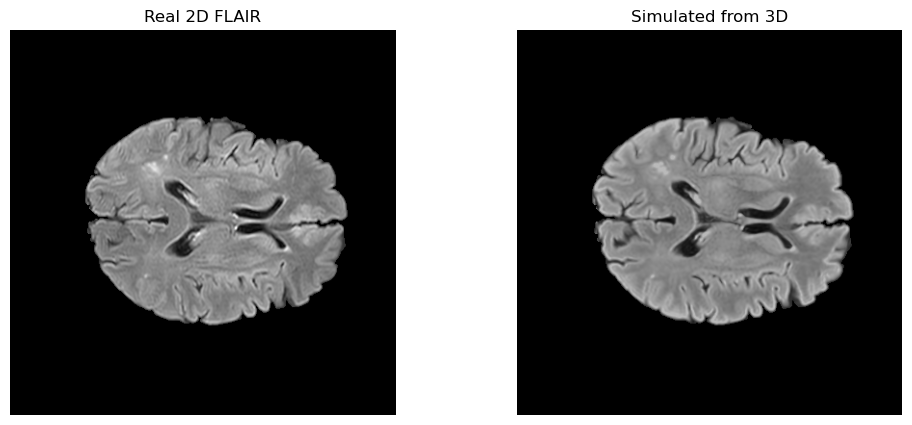

In [37]:
img3d = ants.image_read("1475083Dflair.nii")
img2d_full = ants.image_read("147508T2W_FLAIR.nii")
slice_thickness = img2d_full.spacing[2]

arr2d_full = img2d_full.numpy()
slice_sums = [np.count_nonzero(arr2d_full[:, :, z]) for z in range(arr2d_full.shape[2])]
best_2d_idx = int(np.argmax(slice_sums))
print(f"Best 2D slice index: {best_2d_idx}")

img2d = img2d_full[:, :, best_2d_idx]
ssim_score, psnr_score, ncc_score = run_pipeline(img3d, img2d, slice_thickness, img2d_full, best_2d_idx)